In [1]:


from src.dataset.snow import SnowDataset

dataset_dir = "/Users/samuelthomas/Documents/University/4thYr_Final/ECM3401_Individual_Literature_Review_and_Project/SNOW_Semantic_Segmentation/snow_dataset"
train_dataset = SnowDataset(
    dataset_dir_path=dataset_dir,
    len_override=30,
    resize=True,
    rotate=True,
    augment_image=False,
    normalize=False,
)

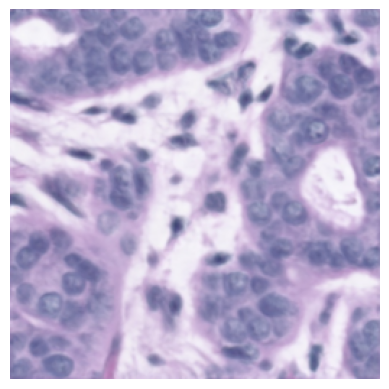

In [12]:
from src.training.visualisation import display_tensor_image

image, mask = train_dataset[0]

display_tensor_image(image)

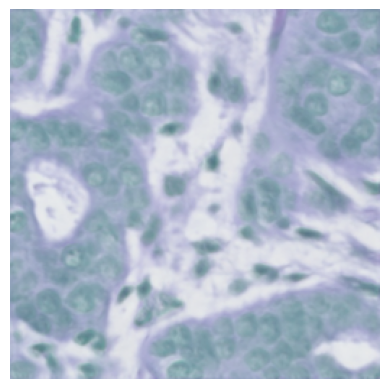

In [119]:
from src.training.visualisation import display_tensor_image
import torchvision.transforms.v2 as _transforms
import random as _random

augmentations = [
    # _transforms.GaussianBlur(kernel_size=5, sigma=(0.3, 0.8)),
    # _transforms.ColorJitter(brightness=(0.8, 1.2)),
    _transforms.ColorJitter(
        contrast=(0.7, 1.3),
        saturation=(0.8, 1.2),
        hue=0.125,
    ),
]
image, mask = train_dataset[0]

# Augment the image
augmentation = _random.choice(augmentations)

bg_only = False
if bg_only:
    # Only apply the augmentation to the background
    image = mask * image + (1 - mask) * augmentation(image)
else:
    image = augmentation(image)

display_tensor_image(image)

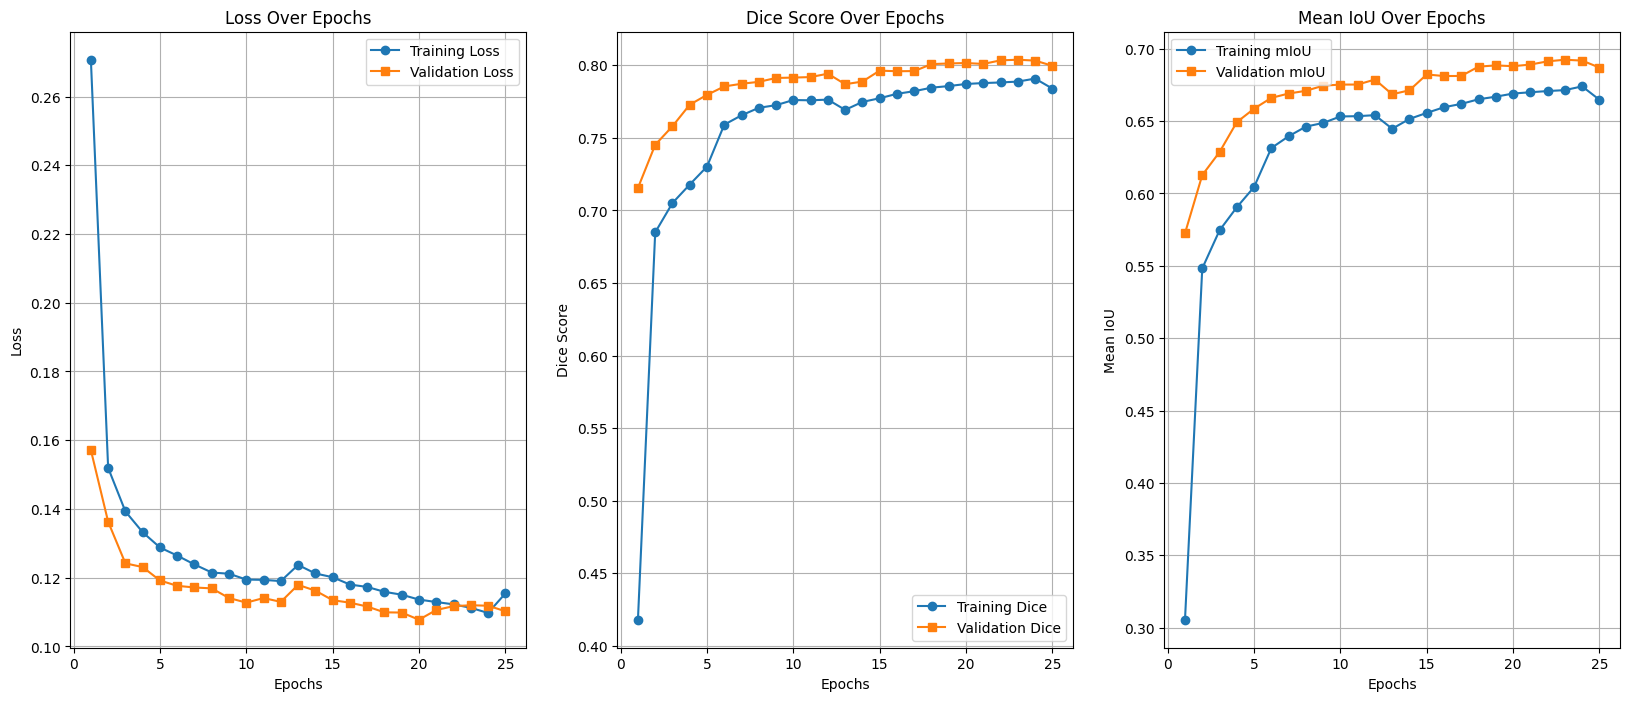

In [1]:
from src.training.visualisation import display_training_metrics

display_training_metrics("results/standard.txt")

No training or validation dice scores found in the log file.
No training or validation mean IoU scores found in the log file.


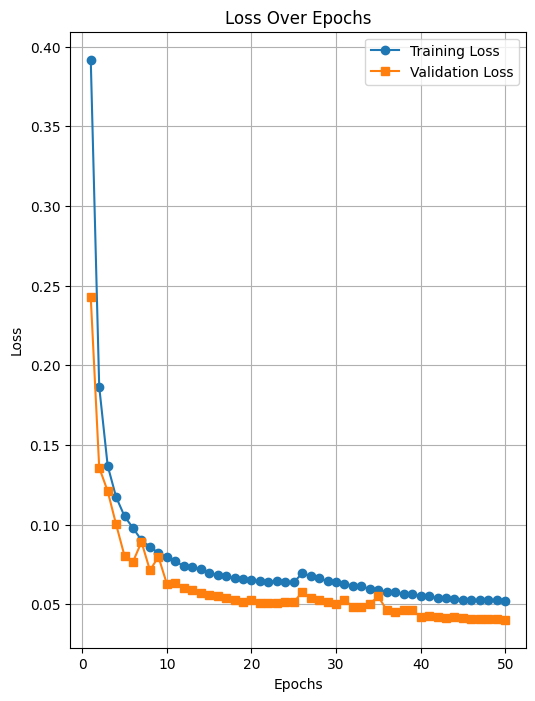

In [2]:
display_training_metrics("results/generative_ssl.txt")

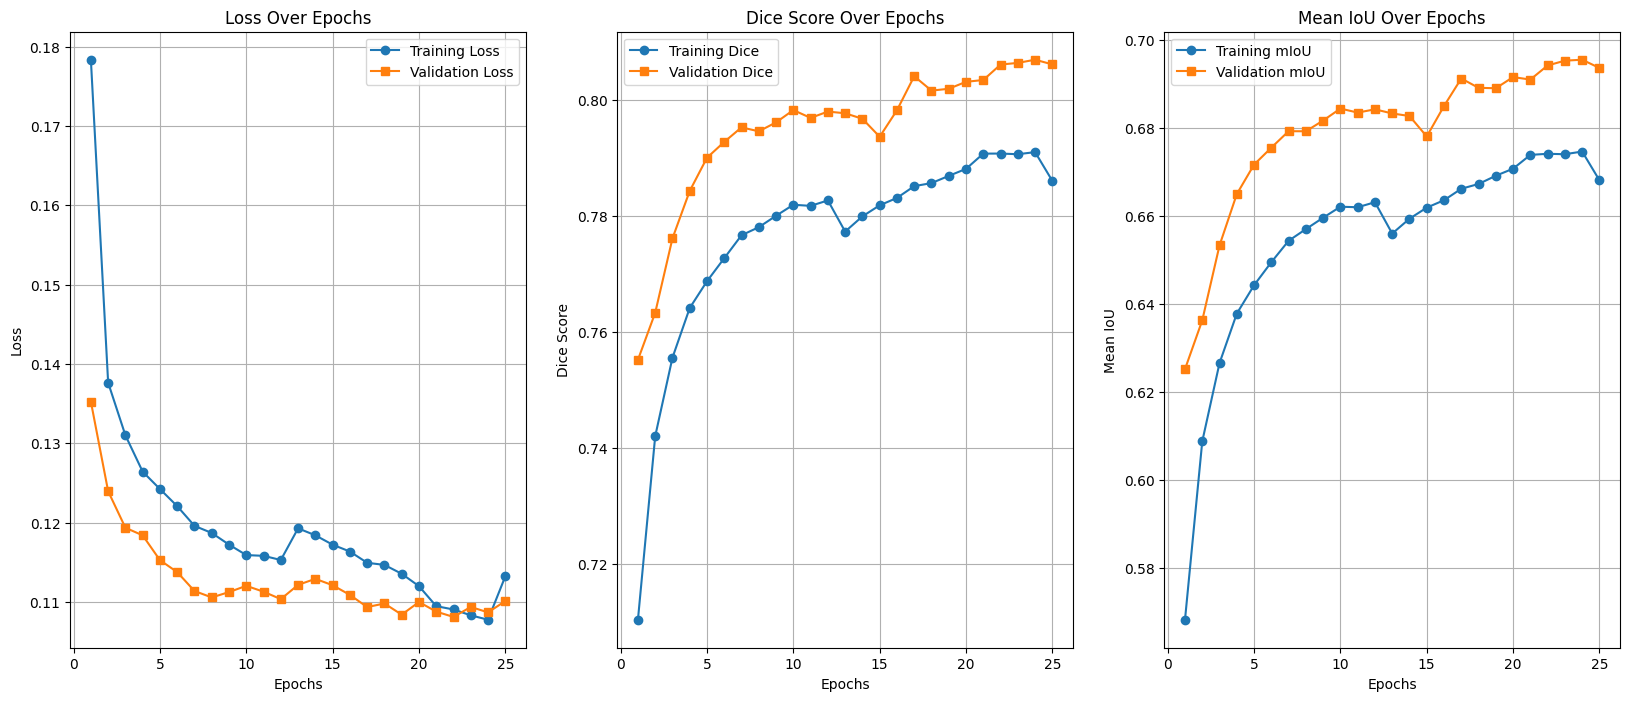

In [4]:
display_training_metrics("results/generative_ssl_finetune.txt")

No training or validation dice scores found in the log file.
No training or validation mean IoU scores found in the log file.


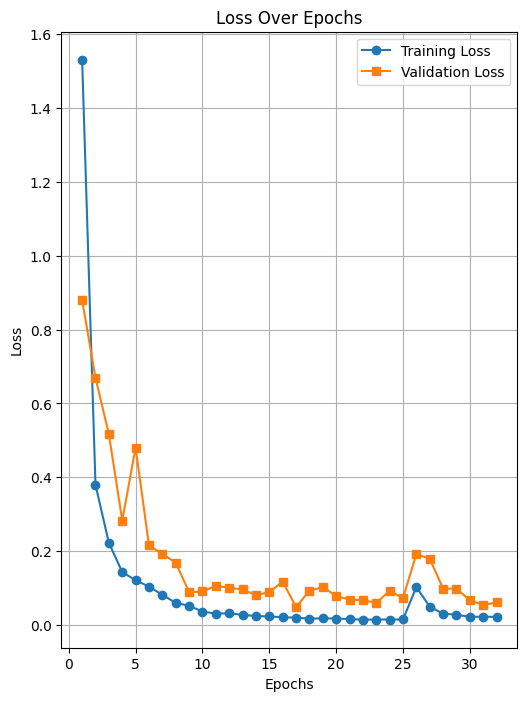

In [3]:
display_training_metrics("results/contrastive_ssl.txt")

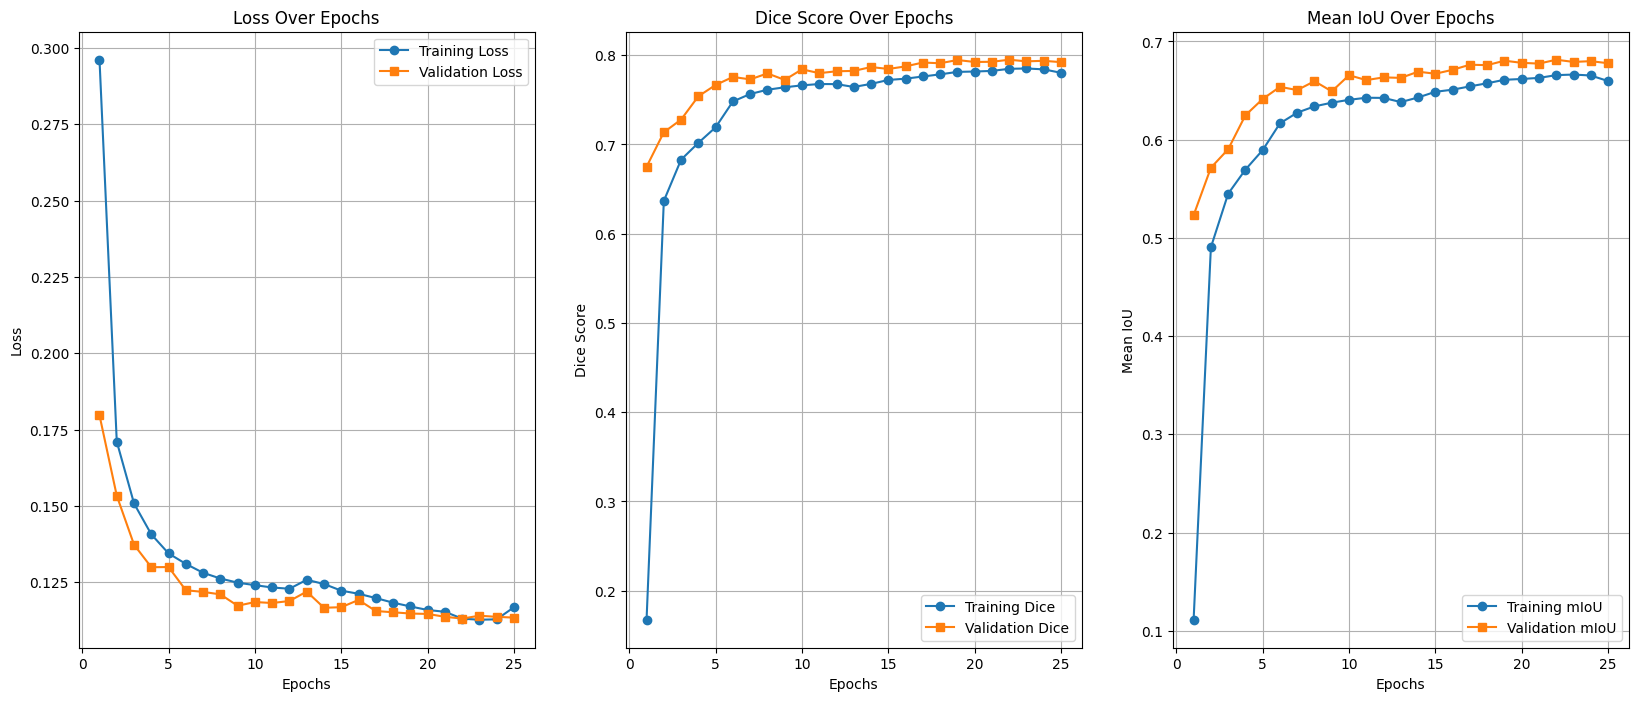

In [5]:
display_training_metrics("results/contrastive_ssl_finetune.txt")